# Semi-Supervised Learning (SSL)


SSL studies how to learn from both labeled and unlabeled data, which can be useful when data is abundant but the resources to label them are limited.

In this exercise, you will:

* Given a simulated dataset with both labeled and unlabeled data, build a similarity graph and use the Harmonic Function Solution (HSF) to predict the labels of the unlabeled data;
* Use HSF for face recognition, given a fixed dataset;
* Implement an online version of HSF to label images as they appear in real time.

## 1. Harmonic Function Solution

Let $G = (V, E)$ be a weighted undirected graph where $V = \{x_1, \ldots, x_n \}$ is the vertex set and $E$ is the edge set. Each edge $e_{ij} \in E$ has a weight $w_{ij}$ and, if there is no edge between $x_i$ and $x_j$, then $w_{ij}=0$.

Let $|V| = n$ be the total number of nodes. Only a subset of the nodes $S \subset V$ with cardinality $|S| = l$ is labeled, and the remaining $u = n - l$ nodes are placed in the subset $T = V \setminus S$.

Our goal is to predict the labels of the vertices in $T$ using the structure of the graph. Since we believe that nodes close in the graph should have similar labels, we would like to have each node surrounded by a majority of nodes with the same label. In order to do so, we impose that the labeling vector $f \in \mathbb{R}^n$ must be an **harmonic function** on the graph, that is:

$$
f_i = \frac{\sum_{j} w_{ij} f_j}{\sum_{j} w_{ij}},  \forall i \in T
$$

One interpretation for this constraint is that $w_{ij}$ represents the tendency of moving from node $x_i$ to node $x_j$, the stationary distribution of the transition matrix $P(j|i) = \tfrac{w_{ij}}{\sum_{k} w_{ik}}$  is a valid solution to our problem.

### Hard HFS

It can be shown that $f$ is harmonic if and only if $(Lf)_T = 0$, where $(Lf)_T$ is the vector containing the values of $Lf$ for the nodes in the set $T$, and $L$ is the graph Laplacian.

Hence, the harmonic function solution to the SSL problem is the solution to the following optimization problem:

$$
\min_{f \in \mathbb{R}^n}  f^T L f  
\quad \text{s.t} \quad
y_i = f(x_i) \quad \forall x_i \in S
$$
where $y_i$ are the labels available for the vertices $x_i \in S$. This gives us:

$$
f_T = L_{TT}^{-1}(W_{TS}f_S) = - L_{TT}^{-1}(L_{TS}f_S)
$$

### Soft HFS

If the labels are noisy, we might need to replace the "hard" constraint of the optimization problem above by a "soft" constraint. Let $C$ be a diagonal matrix such that $C_{ii} = c_l$ for labeled examples and $C_{ii} = c_u$ otherwise. Also, define $y_i = 0$ for unlabeled examples, that is, for $x_i \in T$.

The soft HFS objective function is

$$
\min_{f\in\mathbb{R}^n} (f-y)^T C (f-y) + f^T L f
$$
whose solution is

$$
f^* = (C^{-1}L+I)^{-1}y
$$


### Implementation

Implement hard and soft HFS in the function `compute_hfs`. Complete the function `two_moons_hfs` to test your implementation using the datasets `data_2moons_hfs.mat` and `data_2moons_hfs_large.mat`.


* Tips:
    * Don't forget to choose well the parameters to build the graph and its Laplacian.
    * You can use the functions `build_laplacian_regularized` and `build_similarity_graph`. The function `mask_labels` is used to chose how many labels are revealed.
    * Be careful: the labels are revealed randomly, and each random realization can have different results! Check how the `seed` parameter works.
    * Introduce noisy labels to compare hard and soft HFS.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.spatial.distance as sd
from scipy.io import loadmat
import os
from helper import build_similarity_graph, label_noise
from helper import build_laplacian, build_laplacian_regularized
from helper import plot_classification
from helper import mask_labels

In [2]:
"""
Define parameters for HFS
"""
params = {}

# regularization parameter (gamma)
params['laplacian_regularization'] = 0.0

# the sigma value for the exponential (similarity) function, already squared
params['var'] = 1.0

# Threshold eps for epsilon graphs
params['eps'] = None

# Number of neighbours k for k-nn. If zero, use epsilon-graph
params['k'] = 5

# String selecting which version of the laplacian matrix to construct.
# 'unn':  unnormalized, 'sym': symmetric normalization, 'rw':  random-walk normalization
params['laplacian_normalization'] = 'unn'

# Coefficients for C matrix for soft HFS
params['c_l'] = 1.0
params['c_u'] = 1e-2

In [3]:
def compute_hfs(L, Y, soft=False, **params):
    """
    TO BE COMPLETED

    Function to perform HFS (hard or soft!).

    Parameters
    ----------
    L : array
        Graph Laplacian, (n x n) matrix (regularized or not)
    Y : array
        (n, ) array with nodes labels [0, 1, ... , num_classes] (0 is unlabeled)
    soft : bool
        If True, compute soft HFS. Otherwise, compute hard HFS.

    Returns
    --------
        Labels, class assignments for each of the n nodes
    """

    num_samples = L.shape[0]
    classes = [c for c in np.unique(Y) if c > 0]
    num_classes = len(classes)

    """
    Build the vectors:
    y = (n x num_classes) target vector
    l_idx = shape (l,) vector with indices of labeled nodes
    u_idx = shape (u,) vector with indices of unlabeled nodes
    """
    l_idx = np.where(Y > 0)[0]
    u_idx = np.where(Y == 0)[0]

    y = (Y[:, None] == np.array(classes)).astype(float)

    if not soft:
        """
        Compute hard HFS.

        f_l = solution for labeled data.
        f_u = solution for unlabeled data
        f   = solution for all data
        """
        f = np.zeros((num_samples, num_classes))
        f[l_idx, :] = y[l_idx, :]

        L_TT = L[np.ix_(u_idx, u_idx)]
        L_TS = L[np.ix_(u_idx, l_idx)]

        f_u = - np.linalg.solve(L_TT, L_TS @ f[l_idx, :])
        f[u_idx, :] = f_u


    else:
        """
        Compute soft HFS.
        f = harmonic function solution
        C = (n x n) diagonal matrix with c_l for labeled samples and c_u otherwise
        """
        c_l = params.get('c_l', 1.0)
        c_u = params.get('c_u', 1e-2)

        c_diag = np.zeros(num_samples)
        c_diag[l_idx] = c_l
        c_diag[u_idx] = c_u
        C_inv = np.diag(1.0/c_diag)
        f = np.linalg.solve(C_inv @ L + np.eye(num_samples), y)

    """
    return the labels assignment from the hfs solution, and the solution f
    labels: (n x 1) class assignments [1,2,...,num_classes]
    f : harmonic function solution
    """
    labels = np.argmax(f, axis=1) + 1
    return labels, f


In [4]:
def two_moons_hfs(l=4, l_noisy=1, soft=False, dataset='data_2moons_hfs.mat', plot=True, seed=None, toprint=True, **params):
    """
    TO BE COMPLETED.

    HFS for two_moons data.

    Parameters
    ----------
    l : int
        Number of labeled (unmasked) nodes provided to the HFS algorithm.
    l_noisy : int
        Number of *noisy* labels to introduce.
    soft : bool
        If true, use soft HFS, otherwise use hard HFS
    dataset : {'data_2moons_hfs.mat' or 'data_2moons_hfs_large.mat'}
        Which dataset to use.
    plot : bool
        If True, show plots
    seed : int
        If not None, set global numpy seed before choosing labels to reveal.
    """
    if seed is not None:
        np.random.seed(seed)

    # Load the data. At home, try to use the larger dataset.
    in_data = loadmat(os.path.join('data', dataset))
    X = in_data['X']
    Y = np.array(in_data['Y'].squeeze(), dtype=np.uint32)

    # infer number of labels from samples
    num_samples = np.size(Y, 0)
    unique_classes = np.unique(Y)
    num_classes = len(unique_classes)

    # mask labels
    Y_masked = mask_labels(Y, l, per_class=params.get('per_class', False))
    assert len(np.unique(Y_masked)) > 2, "only one class in training data!"

    # introduce noise
    noise_indices = np.where(Y_masked == 0)[0]
    np.random.shuffle(noise_indices)
    noise_indices = noise_indices[:l_noisy]
    Y_masked[noise_indices] = np.random.choice(unique_classes, l_noisy)

    """
    compute hfs solution using either soft_hfs or hard_hfs
    """
    # Build graph Laplacian using the parameters:
    # params['laplacian_regularization'], params['var'], params['eps'],
    # params['k'] and params['laplacian_normalization'].
    W = build_similarity_graph(
        X,
        var=params.get('var', 1.0),
        eps=params.get('eps', 0),
        k=params.get('k', 0)
    )

    L = build_laplacian(
        W,
        laplacian_normalization=params.get('laplacian_normalization', 'unn')
    )

    reg = params.get('laplacian_regularization', 0.0)
    if reg > 0:
      L += reg * np.eye(L.shape[0])

    labels, f = compute_hfs(L, Y_masked, soft, **params)

    # Visualize results
    if plot:
        plot_classification(
            X, Y, Y_masked, noise_indices, labels,
            params.get('var', 1.0),
            params.get('eps', None),
            params.get('k', 5)
        )

    accuracy = np.mean(labels == np.squeeze(Y))


    if toprint:
      print(f"Soft={soft}, Accuracy={accuracy:.2%}")

    return X, Y, labels, accuracy

### Question 1.1 - Report the accuracy you obtained for `data_2moons_hfs.mat` dataset using hard HFS, when l=10 and l_noisy=0.

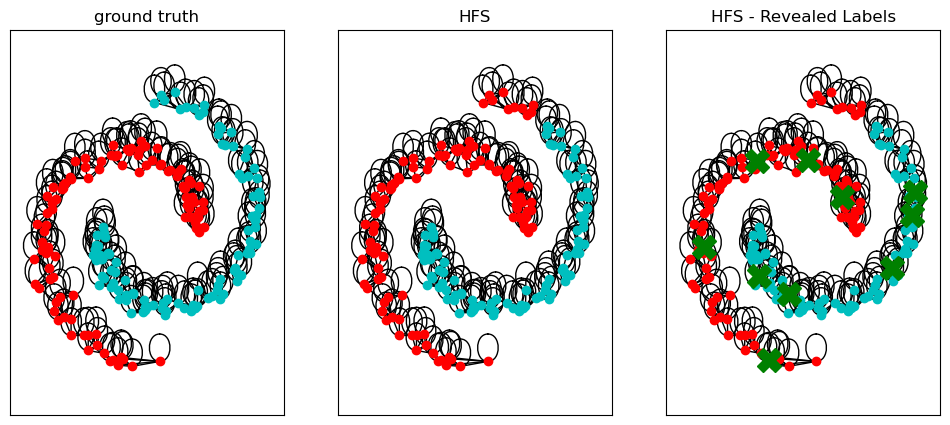

Soft=False, Accuracy=95.00%


In [5]:
seed = 42
X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=0, soft=False, dataset='data_2moons_hfs.mat',
                                                 plot=True, seed=seed, **params)

### Question 1.2  - Using `data_2moons_hfs_large.mat`, run `two_moons_hfs` several times with l=4. What can go wrong?

* Tips:
    * When running `two_moons_hfs` several times, don't forget to set `seed=None`

  
---

In [6]:
np.random.seed(42)
for ii in range(20):
    X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=4, l_noisy=0, soft=False,
                                                     dataset='data_2moons_hfs_large.mat',
                                                     plot=False, seed=None, **params)

AssertionError: only one class in training data!

When running `two_moons_hfs` with `l=4` it is highly possible that all selected elements are from the same ground truth class: with two classes, the probability of that happening is $\frac{1}{2}^{3} = 12.5\%$, assuming that the two clusters are the same size.

A way to fix that is to modify `mask_labels` to force having elements from different classes, at least one of each, but that is not practical in real life.
In the following cell we set `per_class=True` in the code, but not in the cells after that to keep results on real examples.

In [7]:
params['per_class'] = True

np.random.seed(42)
for ii in range(20):
    X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=4, l_noisy=0, soft=False,
                                                     dataset='data_2moons_hfs_large.mat',
                                                     plot=False, seed=None, **params)

Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=81.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=81.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=69.00%
Soft=False, Accuracy=100.00%
Soft=False, Accuracy=81.00%
Soft=False, Accuracy=100.00%


### Question 1.3 - Using `data_2moons_hfs.mat`, l=10 and l_noisy=5, compare hard HFS to soft HFS. Report the accuracy and comment the results.

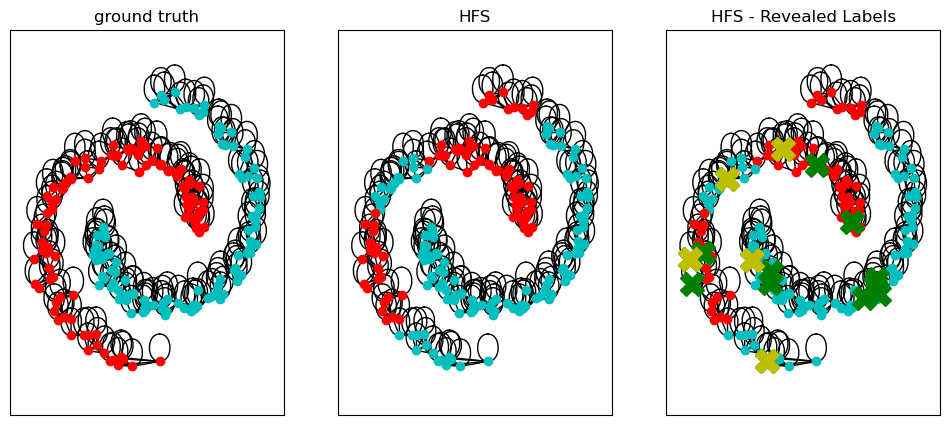

Soft=False, Accuracy=80.00%


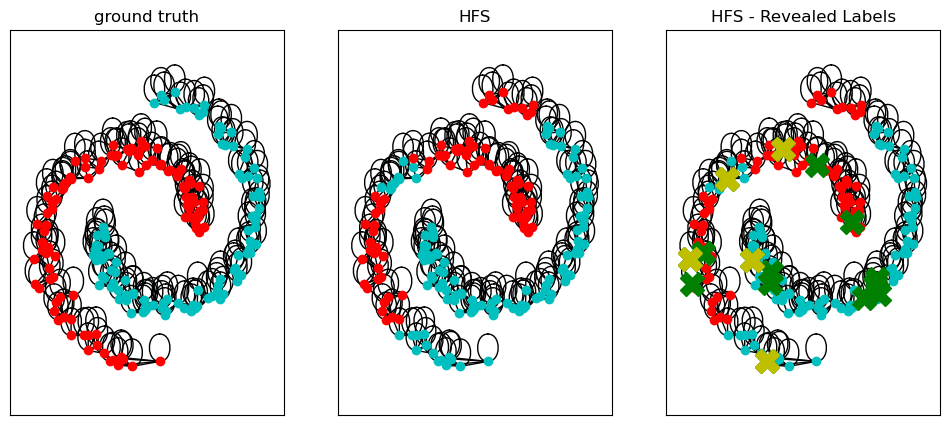

Soft=True, Accuracy=83.00%


In [8]:
params['per_class'] = False

# Comparing
seed = 5  # To run several times with random outcomes, set seed=None. Otherwise, set a seed for reproducibility.
plot = True
dataset = 'data_2moons_hfs.mat' # Try also 'data_2moons_hfs_large.mat'

X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset,
                                                 plot=plot, seed=seed, **params)
X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset,
                                                 plot=plot, seed=seed, **params)

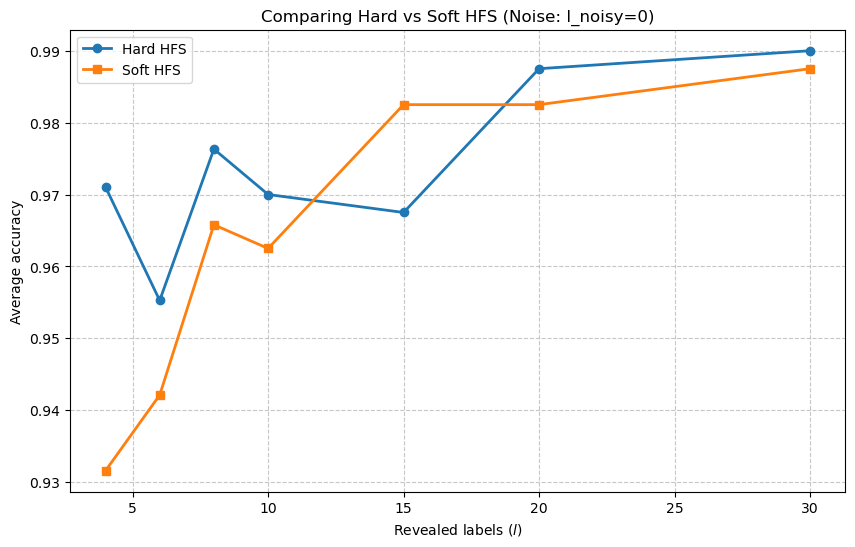

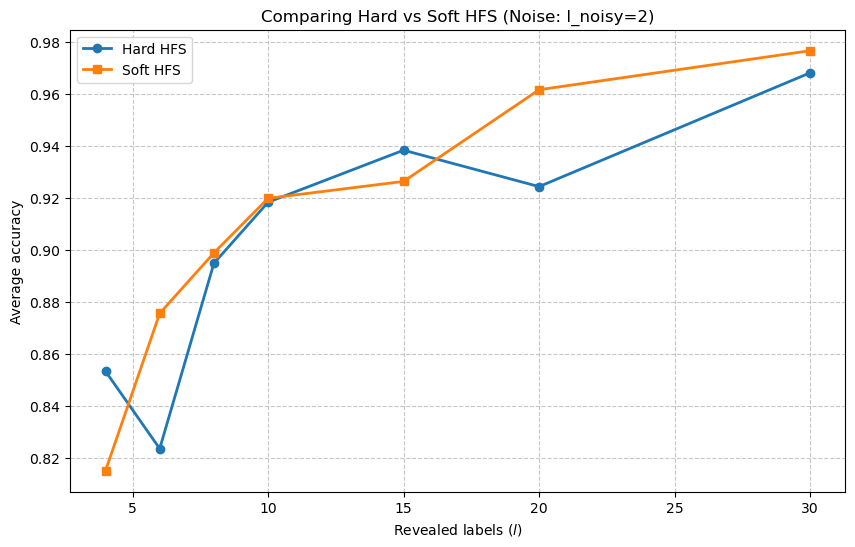

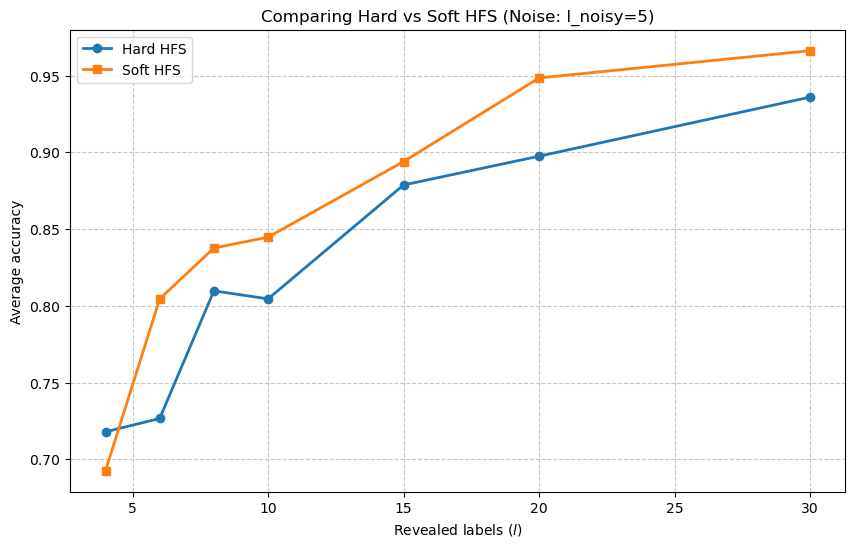

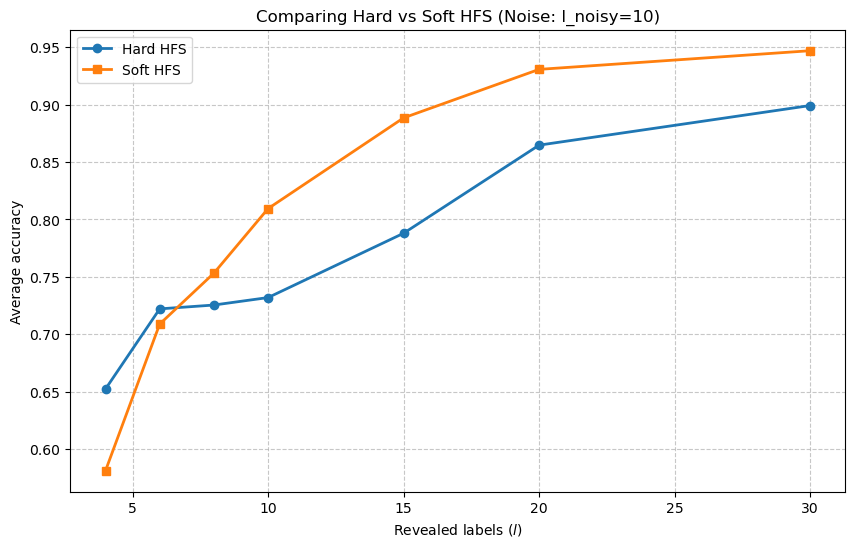

In [9]:
import matplotlib.pyplot as plt

n_iterations = 20
l_values = [4, 6, 8, 10, 15, 20, 30]
l_noisy_values = [0, 2, 5, 10]
dataset = 'data_2moons_hfs.mat'

for l_noisy in l_noisy_values:
  hard_accuracies = []
  soft_accuracies = []
  for l in l_values:
      h_acc_tmp = []
      s_acc_tmp = []

      for i in range(n_iterations):
          try:
              _, _, _, h_acc = two_moons_hfs(l=l, l_noisy=l_noisy, soft=False,
                                            dataset=dataset, plot=False, seed=None, **params, toprint=False)
              _, _, _, s_acc = two_moons_hfs(l=l, l_noisy=l_noisy, soft=True,
                                            dataset=dataset, plot=False, seed=None, **params, toprint=False)

              h_acc_tmp.append(h_acc)
              s_acc_tmp.append(s_acc)
          except AssertionError:
              continue

      hard_accuracies.append(np.mean(h_acc_tmp))
      soft_accuracies.append(np.mean(s_acc_tmp))

  plt.figure(figsize=(10, 6))
  plt.plot(l_values, hard_accuracies, 'o-', label='Hard HFS', linewidth=2)
  plt.plot(l_values, soft_accuracies, 's-', label='Soft HFS', linewidth=2)

  plt.xlabel('Revealed labels ($l$)')
  plt.ylabel('Average accuracy')
  plt.title(f'Comparing Hard vs Soft HFS (Noise: l_noisy={l_noisy})')
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.legend()
  plt.show()

When noise is introduced, the soft HFS performs better than the hard HFS. Indeed, the hard HFS forces label prediction to be made based on the same labels, even though those might be noisy. Since the soft HFS allows for room when choosing the
neighbours from which the prediction is done.


---

## 2. Face recognition with HFS

Now, we apply HFS to the task of face recognition, that is, our goal is to classify faces as belonging to different people. Since faces all share common features, it can be a good idea to leverage a large quantity of unlabeled data to improve classification accuracy. In this part of the exercise, you will:

* Extract faces from the images using OpenCV for face detection, and use the same library to apply preprocessing steps;
* Run HFS for classification.

### Implementation

Choose the hyperparameters and run HFS for face recognition, using both the small and large dataset. You can try to change the preprocessing steps (e.g. equalizeHist, GaussianBlur) applied to the images.

**Important**: make sure your HFS code is able to handle more than two classes!

### Question 2.1 - How did you manage to label more than two classes?



---

There are two main things: the first is that the target matrix Y of labels is a binary matrix of shape $\texttt{num\_samples}\times \texttt{num\_classes}$ and not simply an indicator bitmask.
The second thing is that the final class attribution is not done through a binary decision but by computing the argmaximum of $f$ the score matrix. Considering $f$ as a _confidence_ score, each vertex will receive the label of the class for which its confidence is the highest.

---

### Question 2.2 - Report the best accuracy you obtained for both (small and augmented) datasets.

* Tips:
    * The small dataset (10 images per person) is loaded with `load_image_data`.
    * Use `load_image_data_augmented` for the augmented dataset (50 images per person).


In [10]:
import matplotlib.pyplot as plt
from imageio import imread
import numpy as np
import cv2
import os

from load_images import load_image_data, plot_image_data
from load_images import load_image_data_augmented, plot_image_data_augmented

In [11]:
"""
Define parameters for face recognition with HFS
"""
params_face_rec = {}
params_face_rec['laplacian_regularization'] = 1e-4
params_face_rec['var'] = 10000.0
params_face_rec['eps'] = None
params_face_rec['k'] = 5
params_face_rec['laplacian_normalization'] = 'unn'
params_face_rec['c_l'] = 1.0
params_face_rec['c_u'] = 1e-2

In [12]:
# Function to preprocess the images
# You may try to change it and check the impact on the classification accuracy
def preprocess_image(image):
    """
    Parameters
    ----------
    image : array
        (width, height) array representing a grayscale image

    Returns
    -------
        (96, 96) preprocessed image
    """
    output_frame_size = 96   # do not change the output frame size!
    image = cv2.bilateralFilter(image, 9, 75, 75)
    image = cv2.equalizeHist(image)
    image = cv2.GaussianBlur(image, (5, 5), 0)
    im = cv2.resize(image, (output_frame_size, output_frame_size)).astype(float)
    im -= im.mean()
    im /= im.max()
    image = im
    return image

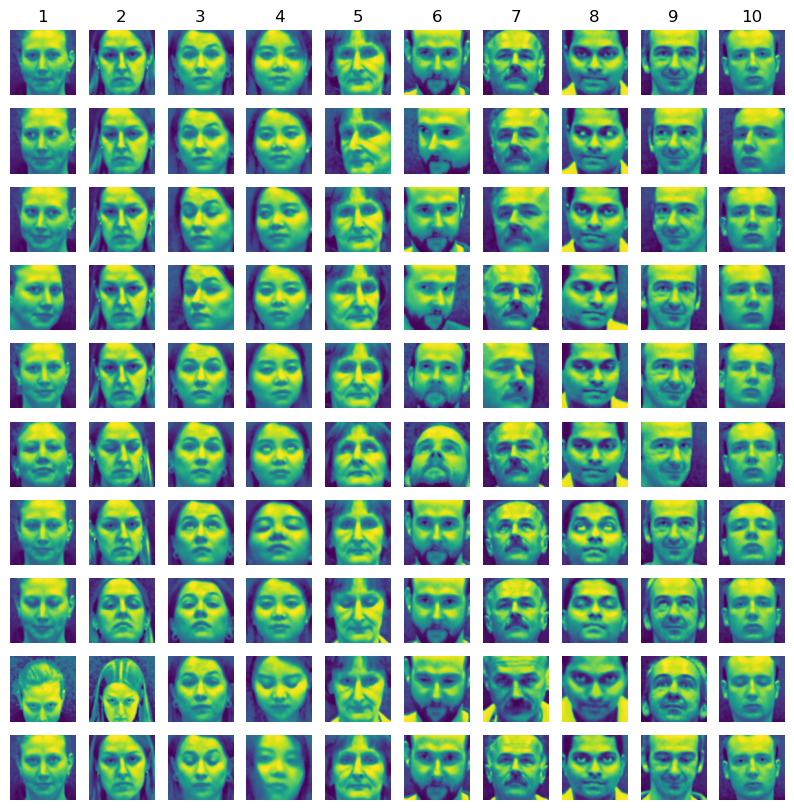

(100, 9216)
[[ 1.  2.  0.  0.  0.  6.  7.  8.  0.  0.]
 [ 1.  2.  0.  4.  0.  0.  7.  0.  0.  0.]
 [ 1.  0.  3.  0.  0.  0.  0.  0.  9.  0.]
 [ 1.  0.  3.  0.  0.  6.  0.  0.  9. 10.]
 [ 0.  0.  0.  4.  5.  6.  0.  8.  0.  0.]
 [ 0.  0.  0.  4.  5.  0.  0.  0.  0.  0.]
 [ 0.  2.  3.  0.  0.  0.  0.  0.  9. 10.]
 [ 0.  0.  0.  0.  5.  6.  7.  0.  0. 10.]
 [ 0.  0.  0.  0.  5.  0.  0.  8.  9. 10.]
 [ 0.  2.  3.  4.  0.  0.  7.  8.  0.  0.]]


In [13]:
# 10 images per person
np.random.seed(456)   # set seed, since labels are masked randomly
images, labels, masked_labels = load_image_data(preprocess_image)

# # 50 images per person
# images_a, labels_a, masked_labels_a = load_image_data_augmented(preprocess_image)
# plot_image_data_augmented(images_a)

# Uncomment below if you want to visualize the images
plot_image_data(images)
print(images.shape)
print(masked_labels.reshape(-1, 10))

In [14]:
# graph Laplacian
L = build_laplacian_regularized(images,
                                params_face_rec['laplacian_regularization'],
                                params_face_rec['var'],
                                params_face_rec['eps'],
                                params_face_rec['k'],
                                params_face_rec['laplacian_normalization'])

Accuracy =  0.73
[ 1.  2.  0.  0.  0.  6.  7.  8.  0.  0.  1.  2.  0.  4.  0.  0.  7.  0.
  0.  0.  1.  0.  3.  0.  0.  0.  0.  0.  9.  0.  1.  0.  3.  0.  0.  6.
  0.  0.  9. 10.  0.  0.  0.  4.  5.  6.  0.  8.  0.  0.  0.  0.  0.  4.
  5.  0.  0.  0.  0.  0.  0.  2.  3.  0.  0.  0.  0.  0.  9. 10.  0.  0.
  0.  0.  5.  6.  7.  0.  0. 10.  0.  0.  0.  0.  5.  0.  0.  8.  9. 10.
  0.  2.  3.  4.  0.  0.  7.  8.  0.  0.]
[ 1  2  4  4  5  6  7  8  9  9  1  2  3  4  3  9  7  8  9  9  1  2  3  3
  5  6  9  8  9  9  1  2  3  3  5  6 10  8  9 10  1  2  4  4  5  6 10  8
 10 10  7  2  4  4  5  4  7  8 10  9  1  2  3  4  5  6  7  4  9 10  1  4
  4  4  5  6  7  4  9 10  5  4  4  3  5  6  8  8  9 10  1  2  3  4  5  6
  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4
  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8
  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2
  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9

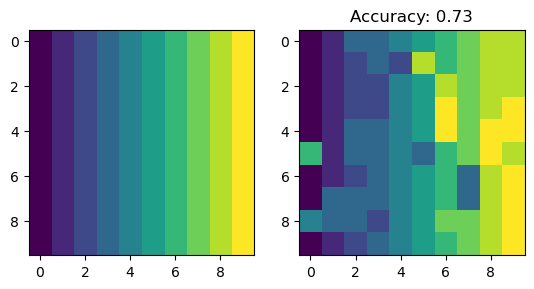

In [15]:
# Run HFS
predicted_labels, f = compute_hfs(L, masked_labels, soft=True, **params_face_rec)
accuracy = np.equal(predicted_labels, labels).mean()
print("Accuracy = ", accuracy)

print(masked_labels)
print(predicted_labels)
print(labels)
# Visualize predicted vs true labels
plt.subplot(121)
plt.imshow(labels.reshape((-1, 10)))
plt.subplot(122)
plt.imshow(predicted_labels.reshape((-1, 10)))
plt.title("Accuracy: {}".format(accuracy))
plt.show()

--- Results for Small Dataset ---
Accuracy = 73.00%


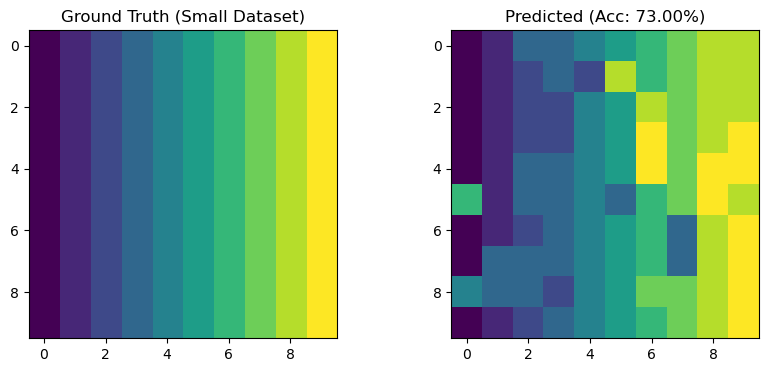

--- Results for Augmented Dataset ---
Accuracy = 58.60%


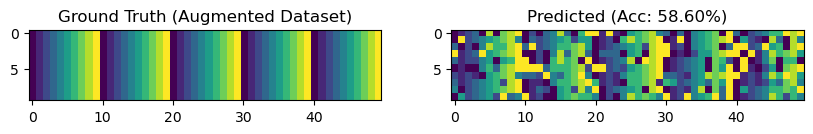

Best Accuracy Small Dataset: 73.00%
Best Accuracy Augmented Dataset: 58.60%


In [16]:
def run_face_recognition(images_data, true_labels, masked_labels, dataset_name):
    """
    Exécute HFS sur un dataset spécifique et affiche l'accuracy.
    """
    L = build_laplacian_regularized(images_data, 
                                    params_face_rec.get('laplacian_regularization', 1e-4), 
                                    params_face_rec.get('var', 10000), 
                                    params_face_rec.get('eps', None), 
                                    params_face_rec.get('k', 6), 
                                    params_face_rec.get('laplacian_normalization', 'unn')
                                   )
    
    predicted_labels, f = compute_hfs(L, masked_labels, soft=True, **params_face_rec)
    
    accuracy = np.equal(predicted_labels, true_labels).mean()
    
    print(f"--- Results for {dataset_name} ---")
    print(f"Accuracy = {accuracy:.2%}")
    
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    n_per_person = 10 if dataset_name == "Small Dataset" else 50
    plt.imshow(true_labels.reshape((-1, n_per_person)))
    plt.title(f"Ground Truth ({dataset_name})")
    
    plt.subplot(122)
    plt.imshow(predicted_labels.reshape((-1, n_per_person)))
    plt.title(f"Predicted (Acc: {accuracy:.2%})")
    plt.show()
    
    return accuracy

np.random.seed(456)
images_s, labels_s, masked_labels_s = load_image_data(preprocess_image)
acc_small = run_face_recognition(images_s, labels_s, masked_labels_s, "Small Dataset")

np.random.seed(456)
images_a, labels_a, masked_labels_a = load_image_data_augmented(preprocess_image)
acc_aug = run_face_recognition(images_a, labels_a, masked_labels_a, "Augmented Dataset")

print(f"Best Accuracy Small Dataset: {acc_small:.2%}")
print(f"Best Accuracy Augmented Dataset: {acc_aug:.2%}")

### Question 2.3 - If the accuracy changes when using the augmented dataset, explain why. Does using additional data always increase the performance?

---

Here, the accuracy diminishes when adding data. There are multiple possible reasons for this phenomenon:

1. The augmented dataset contains 500 images instead of 50, although the new images might not be giving more new information on the faces. If the augmentation contains images that look too similar (pixel by pixel) to another image in the small dataset (say because the new one is a zoom or light change of a previous image), the set of such images will create a dense cluster in the graph, that is disconnected. If too many images look alike in that regard, some pictures of the same person will not be connected to those and the laplacian will get a lot of structural noise.
2. The number of labels revealed is fixed in `load_image_data` to $4 \times \texttt{num\_classes}$ which is not modified when adding more images per class. As such, multiplying the number of images by 5 reduces the proposition of revealed labels by 5.
4. The hyperparameters were not changed in the above test. The variance and the $k$ value used for computing the graph may not be quite as efficient when increasing the size of the graph. Indeed, as images are added, the probability that the graph is less connected increases, and the variance being too small as the distances may increase yields a more cluttered distance distribution.

---

## 3. Online SSL

Now, instead of having all the data available at once, images will be received online: at each time $t$, a new image $x_t$ is observed and the algorithm has to output a label $y_t$.

Use the function `create_user_profile` to capture a training set of labeled data (of your face and someone else). The faces will be preprocessed and saved in the folder `data/faces`. They will be loaded by `online_face_recognition`.


### Implementation

Choose the hyperparameters and complete the functions `online_ssl_update_centroids` and `online_ssl_compute_solution`.

Modify your code to be able to disregard faces it cannot recognize.

* Tips:
    * You can use the functions `build_similarity_graph` and `build_laplacian`.

### Question 3.1 - Attach to this notebook some of the resulting frames of online face recognition.

* Tips:
    * You can save the resulting frame and add it to the notebook in a markdown cell as `![title](picture.png)`

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import os
import sys
from scipy.spatial import distance
import scipy.io as sio

from helper_online_ssl import create_user_profile, online_face_recognition

In [18]:
"""
Define parameters for face recognition with HFS
"""
params_online_ssl = {}
params_online_ssl['laplacian_regularization'] = 0.1
params_online_ssl['var'] = 1000.0
params_online_ssl['eps'] = None
params_online_ssl['k'] = 5
params_online_ssl['laplacian_normalization'] = 'unn'
params_online_ssl['c_l'] = 1.0
params_online_ssl['c_u'] = 1e-2

In [19]:
class IncrementalKCenters:
    def __init__(self, labeled_faces, labels, label_names, max_num_centroids=50):
        #  Number of labels
        self.n_labels = max(labels)

        #  Dimension of the input image
        self.image_dimension = labeled_faces.shape[1]

        #  Check input validity
        assert (set(labels) == set(
            range(1, 1 + self.n_labels))), "Initially provided faces should be labeled in [1, max]"
        assert (len(labeled_faces) == len(labels)), "Initial faces and initial labels are not of same size"

        #  Number of labelled faces
        self.n_labeled_faces = len(labeled_faces)

        # Model parameter : number of maximum stored centroids
        self.max_num_centroids = max_num_centroids

        # Model centroids (inital labeled faces). Shape = (number_of_centroids, dimension)
        self.centroids = labeled_faces

        # Centroids labels
        self.Y = labels

        # Label names (= user names)
        self.label_names = label_names

        # Variables that are initialized in online_ssl_update_centroids()
        self.centroids_distances = None
        self.taboo = None
        self.V = None
        self.init = True

        # index of x_t (initialized later)
        self.last_face = None

    def initialize(self):
        """
        Initialization after the first time that the maximum number of centroids is reached.
        """
        #  Compute the centroids distances
        self.centroids_distances = distance.cdist(self.centroids, self.centroids)

        #  set labeled nodes and self loops as infinitely distant, to avoid merging labeled centroids
        np.fill_diagonal(self.centroids_distances, +np.inf)
        self.centroids_distances[0:self.n_labeled_faces, 0:self.n_labeled_faces] = +np.inf

        # put labeled nodes in the taboo list
        self.taboo = np.array(range(self.centroids.shape[0])) < self.n_labeled_faces

        # initialize multiplicity
        self.V = np.ones(self.centroids.shape[0])


    def online_ssl_update_centroids(self, face):
        """
        TO BE COMPLETED

        Update centroids, multiplicity vector V, labels Y.

        Note: In Y, set label to 0 for unlabeled faces.

        Parameters
        ----------
        face : array
            New sample

        Returns
        --------
        List with the scores for each possible label:
            [(label_1, score_1), (label_2, score_2), ...]
        """

        assert (self.image_dimension == len(face)), "new image not of good size"

        # Case 1: maximum number of centroids has been reached.
        if self.centroids.shape[0] >= self.max_num_centroids + 1:
            if self.init:
                #  Initialization after the first time that the maximum number of centroids is reached
                self.initialize()
                self.init = False
            """
            Find c_rep and c_add following Algorithm 1.

            - c_1, c_2 = two closest centroids (minimum distance) such that at least one of them is not in self.taboo.
            - c_rep = centroid in {c_1, c_2} that is in self.taboo. If none of them is in self.taboo, c_rep is the one
                      with largest multiplicity.
            - c_add = centroid in {c_1, c_2} that is not c_rep.
            """
            c1, c2 = np.unravel_index(np.argmin(self.centroids_distances), self.centroids_distances.shape)
            if self.taboo[c1]:
                c_rep, c_add = c1, c2
            elif self.taboo[c2]:
                c_rep, c_add = c2, c1
            elif self.V[c1] >= self.V[c2]:
                c_rep, c_add = c1, c2
            else:
                c_rep, c_add = c2, c1

            """
            Update data structures: self.centroids and self.V
            """
            self.V[c_rep] += self.V[c_add]
            self.centroids[c_add] = face
            self.V[c_add] = 1

            """
            Update the matrix containing the distances.
            """
            dist_row = distance.cdist(np.array([self.centroids[c_add]]), self.centroids)[0]
            dist_row[c_add] = +np.inf
            self.centroids_distances[c_add, :] = dist_row
            self.centroids_distances[:, c_add] = dist_row
            self.last_face = c_add

        # Case 2: create new centroid with face
        # Remark: the multiplicities vector self.V is initialized in self.initialize()
        else:
            current_len = len(self.centroids)
            self.Y = np.append(self.Y, 0)
            self.centroids = np.vstack([self.centroids, face])

    def online_ssl_compute_solution(self):
        """
        TO BE COMPLETED.

        Returns a prediction corresponding to self.last_face.
        """

        # Multiplicity matrix
        if self.init:
            V = np.diag(np.ones(self.centroids.shape[0]))
            self.last_face = self.centroids.shape[0] - 1
        else:
            V = np.diag(self.V)

        # Build quantized graph and its regularized Laplacian

        W_tilde = build_similarity_graph(self.centroids,
                                         var=params_online_ssl.get('var', 1000),
                                         eps=params_online_ssl.get('eps', None),
                                         k=params_online_ssl.get('k', 5))
        W_g = V @ W_tilde @ V
        L_q = build_laplacian(
            W_g,
            laplacian_normalization=params_online_ssl.get('laplacian_normalization', 'unn')
        )
        Q = L_q + params_online_ssl.get('laplacian_regularization', 0.0) * np.eye(L_q.shape[0])

        # Compute the hard HFS solution f.
        labels, f = compute_hfs(Q, self.Y, soft=False, **params_online_ssl)

        # Return the score for each possible label
        num_classes = len(np.unique(self.Y))-1
        label_scores = []
        for ii in range(num_classes):
            label = self.label_names[ii]
            score = f[self.last_face, ii]
            label_scores.append((label, score))

        max_score = np.max(f[self.last_face, :])
        if max_score < 0.1: # arbitrary value
             label_scores.append(("Unknown", 1.0 - max_score))

        return label_scores

In [37]:
create_user_profile('tonton')         # choose your names here :)
create_user_profile('chirac')
online_face_recognition(['tonton', 'chirac'], IncrementalKCenters, n_pictures=15)

Profile found with 3 images.


[ WARN:0@2454.517] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Profile found with 3 images.


[ WARN:0@2462.709] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Profile found with 3 images.
Profile found with 3 images.


[ WARN:0@2463.628] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


saved
Image saved at results/frame.png
saved
Image saved at results/frame.png


The profiles contain each 3 reference pictures of Jacques Chirac and François Mitterrand (labelled as `Tonton`). The pictures were taken using my laptop camera recording my phone showing photographs taken online.

![Chirac en prison](results/chirac-true.png) ![Tonton au cimetière](results/tonton-true.png) ![Giscard ! Le dernier dinosaure](results/giscard-unknown.png)

As you can see, both Chirac and Mitterrand are well recognized, while Giscard is tagged as unknown.

### Question 3.2 - What strategy did you use to label a face as unknown? Attach to this notebook an example of a unknown face being correctly labeled as unknown.

* Tips
    * If you identify a face as unknown, you can return `[("unknown", score)]` from the function `online_ssl_compute_solution`.


---

In the above version fo the algorithm, we classify as `unknown` any image that has a score lower than a confidence threshold (here set to $0.1$).
Mathematically this means that the new added point is structurally too far of existing clusters in the centroid graph.
An example can be seen on the above picture.

---

### Question 4.1 - You can now classify faces as either known (i.e. belong to a class) or unknown (i.e. belong to no class). How would you modify the algorithm to automatically learn to classify new classes? That is, how can you modify the algorithm so that faces that appear unfrequently are labeled as unknown, but once a specific face has been seen enough times it gets assigned an automatic label (e.g. AutoBob) and from that point it is treated as a new class.

* Tips:
    * Think back to the idea of incremental clustering as unsupervised classification


---

A solution to handle unknown faces as new classes is to "learn" new classes in incremental clustering.
We will use the multiplicity $V$ of the centroids to memorize. If a centroid stays in memory without getting fused with a known class and its multiplicity $V_{i}$ increases, it represents a stable recurrent structure in the data stream.

Once a `unknown` centroid becomes mature enough, say $V_{i} > M$ for a fixed threshold $M$, we create a new label for it, and add its index to the taboo list, preventing it from being absorbed or squished by other points in the future and transforming it into a new class.
It is then simply a matter of updating the label matrix to represent this new class.

The procedure is the following:
1. Treat the new face $x_{l}$ normally through `online_ssl_update_centroids`;
2. If `max_score < threshold`, label it as `unknown`.
3. For the non-taboo centroids with high-multiplicity $V_{i}$, check if they're far enough of known centroids and set the proper variables so that HFS propagates the centroid from the next step on.

---

### Question 4.2 - In class we considered different kinds of metric for (semi) supervised learning. Looking at the face classification task, try to quantify how the offline-online, exact-quantized, and inductive-transductive axes influence each other. In particular given $l$ labeled faces, $u = N - l$ unlabeled faces, and $m$ extra/test faces design an experimental study to quantify these trade-offs, both in terms of transductive and inductive error, as well as online/batch error. Examples of combinations that can be used to study these axes are:
* Supervised vs Semi-supervised
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces.
* Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Supervised vs Semi-supervised and Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces, evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Online vs Batch
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled faces and an online supervised learner (of your choice) trained revealing the $N$ labels one at a time
* Exact vs Quantized
    * A comparison between a semi-supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces using a certain memory budget, and the same learner with a constrained memory budget.
* Exact vs Quantized and Online vs Batch and Inductive vs Transductive
    * A comparison between a semi-supervised online learner (of your choice) trained with and without quantization, evaluated both on the $N$ faces revealed during training, and $m$ faces unrevealed. You can further compare the online performance of the learner against the performance of an "hindsight" learner that saw the labels all at once

--- 

An experimental study that could quantify the tradeoffs that the different approaches have themselves would try to plot the accuracy of classifiers based on:

1. The type of classifier: supervised or semi-supervised, how much data was labeled on the full dataset (the ratio $l/u$) and how much data was revealed to the supervised learner ($l$ or $N$);
2. The type of input: whether the data is passed as one batch, or online through $1 < k \leq N$ batches, and how much pre-training is allowed;
3. The type of memory limitations: with which precision can the graph be computed (reducing the precision $\rho$ of the similarity computation to $10^{-2}$ for example), or how much of the graph can be known at a certain point (reducing the graph to $c$ centroids instead of the full $N + m$ images).

There are multiple parameters to vary, but most importantly one should vary $l, u, N, m$ and $\rho, c$, one at a time to get a $5$-dimensional result set. Moreover, the parameters should not be varied flatly, but as ratios: the important quantity is not the flat number of revealed labels but the number of labels revealed when compared to the number of images. The important variables (some of which are actually co/diaconstrained) are in fact
$l/N$, $l/u$, $l/m$, $N/m$, $c/(N + m)$, $(N + m)/k$, $\rho \times c^{2}$, $c / (N + m)$.
One can then how much each of these parameters influence the results, by running this experiment on multiple input datasets to limit biases. From this we can compute a cross-correlation map for the parameters.

The choice of the metric is also important in the experimental design. The direct choice would be to compare accuracy, but one should also take into account the quantity of data that has to be labeled beforehand for the accuracy to be obtained. Indeed, recognizing a face from a photo when comparing to the faces of everyone in the world is much easier than doing so when comparing to only 10 different faces.
Taking into account computing resources used for the accuracy is really important and it should reflect, which is why we suggest that the trade-off between parameters should be studied across sub-level sets of constraints.
For example, limiting the memory budget should be done flat before computing the impact of the tradeoff between $\rho \times c^{2}$ and $c/(N + m)$ on the accuracy and before knowing the values of $N$ and $m$.
